<a href="https://colab.research.google.com/github/perrymason-droid/ores5160-2026/blob/main/Mini_Health_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Mini Health Data Warehouse
Complete ETL Pipeline (Parts 1–5 Combined)

Stages:
1. Upload & Extract Raw Data (Colab)
2. Standardize & Export Multi‑Format Files
3. Ingestion & Profiling
4. Cleaning, Transformation & Validation
5. Visualization & Summarization

Dataset:
UCI Heart Disease Dataset

Author: Perry Mason Odinga
"""
#===================
#IMPORT REQUIRED LIBRARIES
#========================
import os
import json
import zipfile
import logging
import pandas as pd

from pathlib import Path
from io import StringIO

# =========================================================
# PART 1a — UPLOAD ZIP (GOOGLE COLAB)
# =========================================================

from google.colab import files
uploaded = files.upload()

Saving heart+disease (1).zip to heart+disease (1) (1).zip


In [ ]:
#===================
#LOGGING CONFIGURATION
#======================
logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Starting healthcare ETL pipeline.")

In [ ]:
#===================
#PROJECT DIRECTORY STRUCTURE
#=======================
RAW_DATA_PATH = Path("data/raw")
PROCESSED_DATA_PATH = Path("data/processed")

RAW_DATA_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)


In [ ]:
#===================
#STEP 1 — EXTRACT ZIP DATASET
#========================
with zipfile.ZipFile(
    "heart+disease (1).zip",
    'r'
) as zip_ref:

    zip_ref.extractall(RAW_DATA_PATH)

print("ZIP extracted successfully.")
logging.info("ZIP dataset extracted successfully.")

ZIP extracted successfully.


In [ ]:
#===================
#STEP 2 — VERIFY EXTRACTED FILES
#========================import os

print(os.listdir("data/raw"))

['switzerland.data', 'bak', 'long-beach-va.data', 'Index', 'cleveland.data', 'costs', 'ask-detrano', 'hungarian.data', 'heart-disease.names', 'processed.va.data', 'heart_disease.csv', 'processed.hungarian.data', 'processed.cleveland.data', 'heart_disease.json', 'new.data', 'reprocessed.hungarian.data', 'cleve.mod', 'processed.switzerland.data', 'heart_disease_report.html', 'WARNING']


In [ ]:
#===================
#STEP 3 — RENAME RAW DATASET
#=========================
import os

os.rename(
    "data/raw/processed.cleveland.data",
    "data/raw/heart_disease.csv"
)

print("Dataset renamed successfully.")

Dataset renamed successfully.


In [ ]:
#===================
#STEP 4 — DEFINE OFFICIAL COLUMN NAMES
#==============================

columns = [
    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'target'
]

In [ ]:
#===================
#STEP 5 — LOAD RAW CSV DATA
#=======================
CSV_FILE = RAW_DATA_PATH / "heart_disease.csv"

df = pd.read_csv(
    CSV_FILE,
    header=None,
    names=columns,
    na_values='?'
)

print("CSV dataset loaded successfully.")
logging.info("CSV dataset loaded successfully.")

CSV dataset loaded successfully.


In [ ]:
#===================
#STEP 6 — EXPORT STANDARDIZED FILE FORMATS
#==================================
JSON_FILE = RAW_DATA_PATH / "heart_disease.json"
HTML_FILE = RAW_DATA_PATH / "heart_disease_report.html"

# Save cleaned CSV

df.to_csv(
    CSV_FILE,
    index=False
)

# Save JSON version

df.to_json(
    JSON_FILE,
    orient="records",
    indent=4
)

# Save HTML report

html_table = df.to_html(index=False)

with open(
    HTML_FILE,
    "w",
    encoding="utf-8"
) as file:

    file.write(html_table)

print("Multi-format files created successfully.")
logging.info("CSV, JSON, and HTML files created successfully.")

Multi-format files created successfully.


In [ ]:
#===================
#STEP 7 — DATA INGESTION FUNCTIONS
#=========================================================
#FUNCTION: LOAD CSV DATA
def load_csv_data(file_path):

    try:

        df = pd.read_csv(
            file_path,
            encoding='utf-8',
            na_values='?'
        )

        logging.info(f"CSV file loaded successfully: {file_path}")

        print("\nCSV DATA LOADED SUCCESSFULLY")
        print(df.head())

        return df

    except FileNotFoundError:

        logging.error(f"CSV file not found: {file_path}")
        print("Error: CSV file not found.")

    except pd.errors.ParserError:

        logging.error("CSV parsing error.")
        print("Error: Unable to parse CSV file.")

    except Exception as e:

        logging.error(f"Unexpected CSV loading error: {e}")
        print(f"Unexpected error: {e}")

In [ ]:
#FUNCTION: LOAD JSON DATA
def load_json_data(file_path):

    try:

        with open(
            file_path,
            'r',
            encoding='utf-8'
        ) as file:

            data = json.load(file)

        df = pd.json_normalize(data)

        logging.info(f"JSON file loaded successfully: {file_path}")

        print("\nJSON DATA LOADED SUCCESSFULLY")
        print(df.head())

        return df

    except FileNotFoundError:

        logging.error(f"JSON file not found: {file_path}")
        print("Error: JSON file not found.")

    except json.JSONDecodeError:

        logging.error("Invalid JSON format.")
        print("Error: JSON decoding failed.")

    except Exception as e:

        logging.error(f"Unexpected JSON loading error: {e}")
        print(f"Unexpected error: {e}")

In [ ]:
#FUNCTION: LOAD HTML DATA
def load_html_data(file_path):

    try:

        with open(
            file_path,
            "r",
            encoding="utf-8"
        ) as file:

            html_content = file.read()

        tables = pd.read_html(
            StringIO(html_content)
        )

        df = tables[0]

        logging.info(f"HTML file loaded successfully: {file_path}")

        print("\nHTML DATA LOADED SUCCESSFULLY")
        print(df.head())

        return df

    except ValueError:

        logging.error("No tables found in HTML file.")
        print("Error: No HTML tables detected.")

    except FileNotFoundError:

        logging.error(f"HTML file not found: {file_path}")
        print("Error: HTML file not found.")

    except Exception as e:

        logging.error(f"Unexpected HTML loading error: {e}")
        print(f"Unexpected error: {e}")

In [ ]:
#===================
#STEP 8 — INITIAL DATA PROFILING FUNCTION
#=================================
def profile_dataset(df, dataset_name):

    try:

        print(f"\n{'='*60}")
        print(f"DATA PROFILE: {dataset_name}")
        print(f"{'='*60}")

        print("\nShape:")
        print(df.shape)

        print("\nColumns:")
        print(df.columns.tolist())

        print("\nData Types:")
        print(df.dtypes)

        print("\nMissing Values:")
        print(df.isnull().sum())

        print("\nDuplicate Records:")
        print(df.duplicated().sum())

        print("\nSummary Statistics:")
        print(df.describe(include='all'))

        logging.info(
            f"Profiling completed for {dataset_name}"
        )

    except Exception as e:

        logging.error(
            f"Profiling error for {dataset_name}: {e}"
        )

In [ ]:
#===================
#STEP 9 — MAIN PIPELINE EXECUTION
#=============================
if __name__ == "__main__":

    print("\nSTARTING HEALTHCARE DATA INGESTION PIPELINE")

    # -----------------------------------------------------
    # LOAD CSV DATA
    # -----------------------------------------------------

    csv_df = load_csv_data(CSV_FILE)

    if csv_df is not None:

        profile_dataset(
            csv_df,
            "CSV Heart Disease Data"
        )

    # -----------------------------------------------------
    # LOAD JSON DATA
    # -----------------------------------------------------

    json_df = load_json_data(JSON_FILE)

    if json_df is not None:

        profile_dataset(
            json_df,
            "JSON Heart Disease Data"
        )

    # -----------------------------------------------------
    # LOAD HTML DATA
    # -----------------------------------------------------

    html_df = load_html_data(HTML_FILE)

    if html_df is not None:

        profile_dataset(
            html_df,
            "HTML Heart Disease Report"
        )

    # -----------------------------------------------------
    # SAVE PROCESSED COPIES
    # -----------------------------------------------------

    try:

        if csv_df is not None:

            csv_df.to_csv(
                PROCESSED_DATA_PATH /
                "processed_heart_disease.csv",
                index=False
            )

        if json_df is not None:

            json_df.to_csv(
                PROCESSED_DATA_PATH /
                "processed_heart_disease_json.csv",
                index=False
            )

        if html_df is not None:

            html_df.to_csv(
                PROCESSED_DATA_PATH /
                "processed_heart_disease_html.csv",
                index=False
            )

        logging.info(
            "Processed datasets saved successfully."
        )

        print(
            "\nProcessed datasets saved successfully."
        )

    except Exception as e:

        logging.error(
            f"Error saving processed files: {e}"
        )

        print(f"Saving error: {e}")

    logging.info(
        "Data ingestion pipeline completed."
    )

    print(
        "\nDATA INGESTION PIPELINE COMPLETED"
    )



STARTING HEALTHCARE DATA INGESTION PIPELINE

CSV DATA LOADED SUCCESSFULLY
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

DATA PROFILE: CSV Heart Disease Data

Shape:
(303, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64


In [ ]:
# Mini Health Data Warehouse
# Part 2: Cleaning, Transformation & Validation
# Dataset: UCI Heart Disease Dataset
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import logging
from pathlib import Path

# =========================================================
# LOGGING CONFIGURATION
# =========================================================

logging.basicConfig(
    filename='cleaning_validation.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Starting cleaning and validation pipeline.")

# =========================================================
# FILE PATHS
# =========================================================

INPUT_FILE = Path("data/processed/processed_heart_disease.csv")
OUTPUT_FILE = Path("data/processed/cleaned_heart_disease.csv")

# =========================================================
# LOAD DATASET
# =========================================================

try:
    df = pd.read_csv(INPUT_FILE)

    logging.info("Dataset loaded successfully.")

    print("\nDATASET LOADED SUCCESSFULLY")
    print(df.head())

except FileNotFoundError:
    logging.error(f"Input file not found: {INPUT_FILE}")
    print("Error: Input dataset not found.")

except Exception as e:
    logging.error(f"Unexpected loading error: {e}")
    print(f"Unexpected error: {e}")

# =========================================================
# COLUMN STANDARDIZATION
# =========================================================

try:

    # Standardize column names
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    logging.info("Column names standardized.")

except Exception as e:
    logging.error(f"Column standardization error: {e}")

# =========================================================
# COLUMN RENAMING
# =========================================================

try:

    column_mapping = {
        'cp': 'chest_pain_type',
        'trestbps': 'resting_blood_pressure',
        'chol': 'cholesterol',
        'thalach': 'maximum_heart_rate',
        'exang': 'exercise_induced_angina',
        'oldpeak': 'st_depression',
        'ca': 'major_vessels',
        'target': 'heart_disease'
    }

    df.rename(columns=column_mapping, inplace=True)

    logging.info("Columns renamed successfully.")

except Exception as e:
    logging.error(f"Column renaming error: {e}")

# =========================================================
# DATATYPE CONVERSION
# =========================================================

try:

    numeric_columns = [
        'age',
        'resting_blood_pressure',
        'cholesterol',
        'maximum_heart_rate',
        'st_depression',
        'major_vessels'
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors='coerce'
        )

    logging.info("Datatype conversion completed.")

except Exception as e:
    logging.error(f"Datatype conversion error: {e}")

# =========================================================
# HANDLE MISSING VALUES
# =========================================================

try:

    print("\nMISSING VALUES BEFORE CLEANING")
    print(df.isnull().sum())

    # Fill numeric missing values with median
    for column in numeric_columns:
        df[column] = df[column].fillna(
            df[column].median()
        )

    # Fill categorical missing values
    categorical_columns = [
        'sex',
        'chest_pain_type',
        'heart_disease'
    ]

    for column in categorical_columns:
        df[column] = df[column].fillna('Unknown')

    logging.info("Missing values handled successfully.")

except Exception as e:
    logging.error(f"Missing value handling error: {e}")

# =========================================================
# REMOVE DUPLICATES
# =========================================================

try:

    duplicates_before = df.duplicated().sum()

    df.drop_duplicates(inplace=True)

    duplicates_after = df.duplicated().sum()

    logging.info(
        f"Duplicates removed: "
        f"{duplicates_before - duplicates_after}"
    )

    print(f"\nDuplicates Removed: {duplicates_before}")

except Exception as e:
    logging.error(f"Duplicate removal error: {e}")

# =========================================================
# VALIDATION FUNCTIONS
# =========================================================

def validate_age(age):
    """
    Validate patient age.

    Parameters:
        age (int or float)

    Returns:
        bool
    """

    if age < 0 or age > 120:
        raise ValueError(f"Invalid age detected: {age}")

    return True


def validate_cholesterol(cholesterol):
    """
    Validate cholesterol values.

    Parameters:
        cholesterol (int or float)

    Returns:
        bool
    """

    if cholesterol < 50 or cholesterol > 700:
        raise ValueError(
            f"Abnormal cholesterol value detected: {cholesterol}"
        )

    return True


def validate_blood_pressure(bp):
    """
    Validate resting blood pressure.

    Parameters:
        bp (int or float)

    Returns:
        bool
    """

    if bp < 50 or bp > 300:
        raise ValueError(
            f"Invalid blood pressure value detected: {bp}"
        )

    return True

# =========================================================
# APPLY VALIDATION CHECKS
# =========================================================

try:

    for value in df['age']:
        validate_age(value)

    for value in df['cholesterol']:
        validate_cholesterol(value)

    for value in df['resting_blood_pressure']:
        validate_blood_pressure(value)

    logging.info("Validation checks completed successfully.")

    print("\nVALIDATION CHECKS COMPLETED")

except ValueError as validation_error:

    logging.error(validation_error)

    print(f"Validation Error: {validation_error}")

except Exception as e:

    logging.error(f"Unexpected validation error: {e}")

# =========================================================
# OUTLIER DETECTION
# =========================================================

try:

    outlier_columns = [
        'cholesterol',
        'resting_blood_pressure',
        'maximum_heart_rate'
    ]

    for column in outlier_columns:

        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)

        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df[
            (df[column] < lower_bound) |
            (df[column] > upper_bound)
        ]

        print(f"\nOUTLIERS DETECTED IN {column.upper()}")
        print(outliers[[column]].head())

        logging.info(
            f"{len(outliers)} outliers detected in {column}"
        )

except Exception as e:

    logging.error(f"Outlier detection error: {e}")

# =========================================================
# LOGICAL ERROR CHECKS
# =========================================================

try:

    # Example logical inconsistency:
    # Maximum heart rate should not exceed 250

    logical_errors = df[
        df['maximum_heart_rate'] > 250
    ]

    if len(logical_errors) > 0:

        logging.warning(
            f"Logical errors detected: "
            f"{len(logical_errors)} records"
        )

        print("\nLOGICAL ERRORS DETECTED")
        print(logical_errors)

    else:

        print("\nNO LOGICAL ERRORS DETECTED")

except Exception as e:

    logging.error(f"Logical error validation failed: {e}")

# =========================================================
# FINAL DATASET SUMMARY
# =========================================================

try:

    print("\nFINAL DATASET SUMMARY")
    print("=" * 50)

    print("\nDataset Shape:")
    print(df.shape)

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values After Cleaning:")
    print(df.isnull().sum())

    logging.info("Final profiling completed.")

except Exception as e:

    logging.error(f"Final profiling error: {e}")

# =========================================================
# SAVE CLEANED DATASET
# =========================================================

try:

    df.to_csv(
        OUTPUT_FILE,
        index=False
    )

    logging.info(
        f"Cleaned dataset saved successfully: {OUTPUT_FILE}"
    )

    print("\nCLEANED DATASET SAVED SUCCESSFULLY")

except Exception as e:

    logging.error(f"Saving cleaned dataset failed: {e}")

    print(f"Saving error: {e}")

# =========================================================
# PIPELINE COMPLETE
# =========================================================

logging.info("Cleaning and validation pipeline completed.")




DATASET LOADED SUCCESSFULLY
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

MISSING VALUES BEFORE CLEANING
age                        0
sex                        0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fbs                        0
restecg                    0
maximum_heart_rate         0
exercise_induced_angina    0
st_depression              0
slope 

In [ ]:
"""
Mini Health Data Warehouse
Part 3: Reshaping & Integration
"""

import pandas as pd
import logging
from pathlib import Path

# =========================================================
# LOGGING
# =========================================================

logging.basicConfig(
    filename='reshaping_integration.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# =========================================================
# PATHS
# =========================================================

INPUT_FILE = Path("data/processed/cleaned_heart_disease.csv")
OUTPUT_PATH = Path("data/processed")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv(INPUT_FILE)

# FIX: stable patient ID
df.insert(0, "patient_id", range(1, len(df) + 1))

logging.info("Dataset loaded with patient_id.")

print("\nDATA LOADED")
print(df.head())

# =========================================================
# SAFE COLUMN MAPPING
# =========================================================

def safe_col(df, col):
    return col if col in df.columns else None

# handle possible naming differences
chol_col = safe_col(df, "cholesterol")
bp_col = safe_col(df, "resting_blood_pressure")
hr_col = safe_col(df, "max_heart_rate") or safe_col(df, "maximum_heart_rate")
target_col = safe_col(df, "heart_disease")

# =========================================================
# PATIENT TABLE
# =========================================================

patients_df = df[[
    "patient_id",
    "age",
    "sex",
    target_col
]].copy()

logging.info("Patient table created.")

# =========================================================
# CLINICAL TABLE
# =========================================================

clinical_cols = [
    bp_col,
    chol_col,
    hr_col
]

clinical_df = df[["patient_id"] + clinical_cols].copy()

logging.info("Clinical table created.")

# =========================================================
# MERGE (FACT TABLE)
# =========================================================

merged_df = pd.merge(patients_df, clinical_df, on="patient_id")

logging.info("Merged fact table created.")

print("\nMERGED FACT TABLE")
print(merged_df.head())

# =========================================================
# STRONGER PIVOT (MORE ANALYTICAL VALUE)
# =========================================================

pivot_table = merged_df.pivot_table(
    index="heart_disease",
    columns="sex",
    values=chol_col,
    aggfunc=["mean", "median"]
)

print("\nPIVOT TABLE (Cholesterol Analysis)")
print(pivot_table)

logging.info("Pivot completed.")

# =========================================================
# MELT (LONG FORMAT)
# =========================================================

melted_df = pd.melt(
    merged_df,
    id_vars=["patient_id", "heart_disease"],
    value_vars=[bp_col, chol_col, hr_col],
    var_name="clinical_measure",
    value_name="value"
)

logging.info("Melt completed.")

print("\nMELTED DATA")
print(melted_df.head())

# =========================================================
# AGGREGATION
# =========================================================

summary = merged_df.groupby("heart_disease").agg({
    chol_col: "mean",
    bp_col: "mean",
    hr_col: "mean"
})

print("\nSUMMARY STATS")
print(summary)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

merged_df["risk_flag"] = (
    (merged_df[chol_col] > 240) |
    (merged_df[bp_col] > 140)
).astype(int)

logging.info("Feature engineering completed.")

print("\nFEATURE ENGINEERING SAMPLE")
print(merged_df[["patient_id", "risk_flag"]].head())

# =========================================================
# SAVE OUTPUTS
# =========================================================

patients_df.to_csv(OUTPUT_PATH / "dim_patients.csv", index=False)
clinical_df.to_csv(OUTPUT_PATH / "fact_clinical.csv", index=False)
merged_df.to_csv(OUTPUT_PATH / "fact_heart_disease.csv", index=False)
melted_df.to_csv(OUTPUT_PATH / "melted_clinical.csv", index=False)

logging.info("All datasets saved.")

print("\nTRANSFORMATION COMPLETE")
print("Shapes:")
print("Patients:", patients_df.shape)
print("Clinical:", clinical_df.shape)
print("Merged:", merged_df.shape)
print("Melted:", melted_df.shape)


DATA LOADED
   patient_id   age  sex  chest_pain_type  resting_blood_pressure  \
0           1  63.0  1.0              1.0                   145.0   
1           2  67.0  1.0              4.0                   160.0   
2           3  67.0  1.0              4.0                   120.0   
3           4  37.0  1.0              3.0                   130.0   
4           5  41.0  0.0              2.0                   130.0   

   cholesterol  fbs  restecg  maximum_heart_rate  exercise_induced_angina  \
0        233.0  1.0      2.0               150.0                      0.0   
1        286.0  0.0      2.0               108.0                      1.0   
2        229.0  0.0      2.0               129.0                      1.0   
3        250.0  0.0      0.0               187.0                      0.0   
4        204.0  0.0      2.0               172.0                      0.0   

   st_depression  slope  major_vessels  thal  heart_disease  
0            2.3    3.0            0.0   6.0   

ERROR:root:Dataset not found: data/processed/merged_heart_disease_data.csv


Error: Dataset file not found.

DATASET SUMMARY

Dataset Shape:
(303, 15)

Dataset Columns:
['patient_id', 'age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholesterol', 'fbs', 'restecg', 'maximum_heart_rate', 'exercise_induced_angina', 'st_depression', 'slope', 'major_vessels', 'thal', 'heart_disease']

Missing Values:
patient_id                 0
age                        0
sex                        0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fbs                        0
restecg                    0
maximum_heart_rate         0
exercise_induced_angina    0
st_depression              0
slope                      0
major_vessels              0
thal                       2
heart_disease              0
dtype: int64

Descriptive Statistics:
       patient_id         age         sex  chest_pain_type  \
count  303.000000  303.000000  303.000000       303.000000   
mean   152.000000   54.438944    0.679868         3.158416   
std     

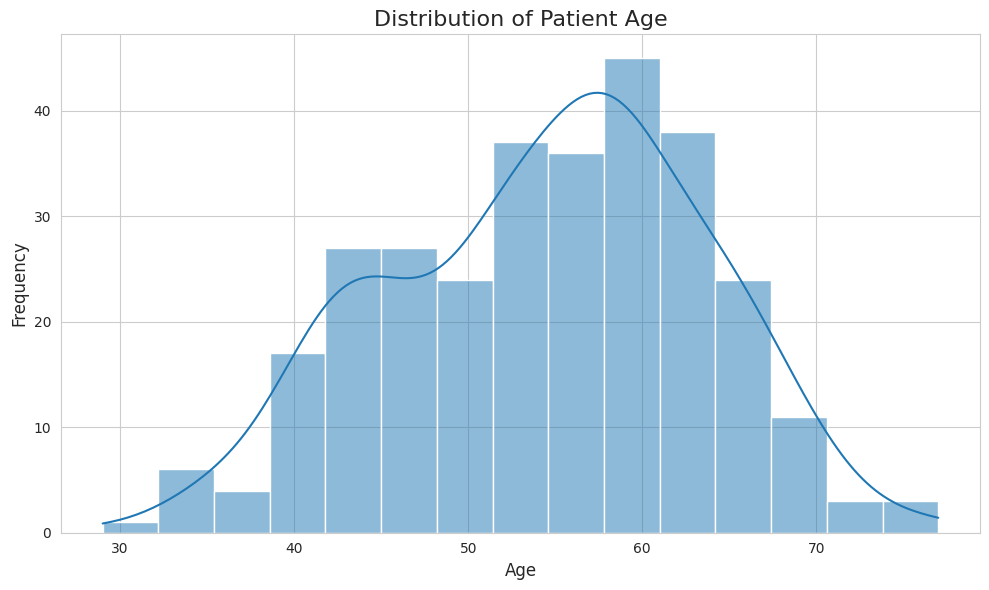

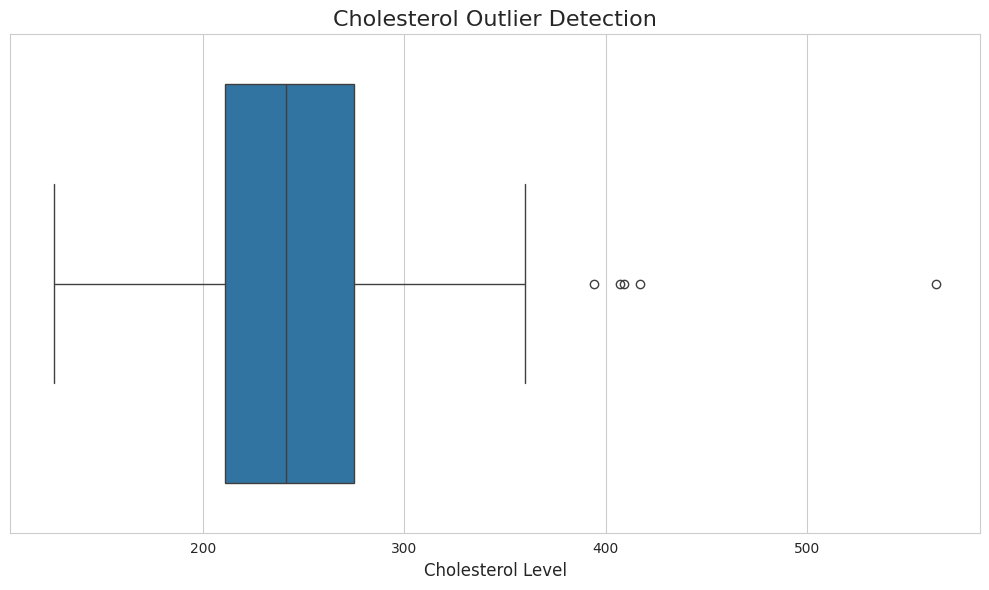

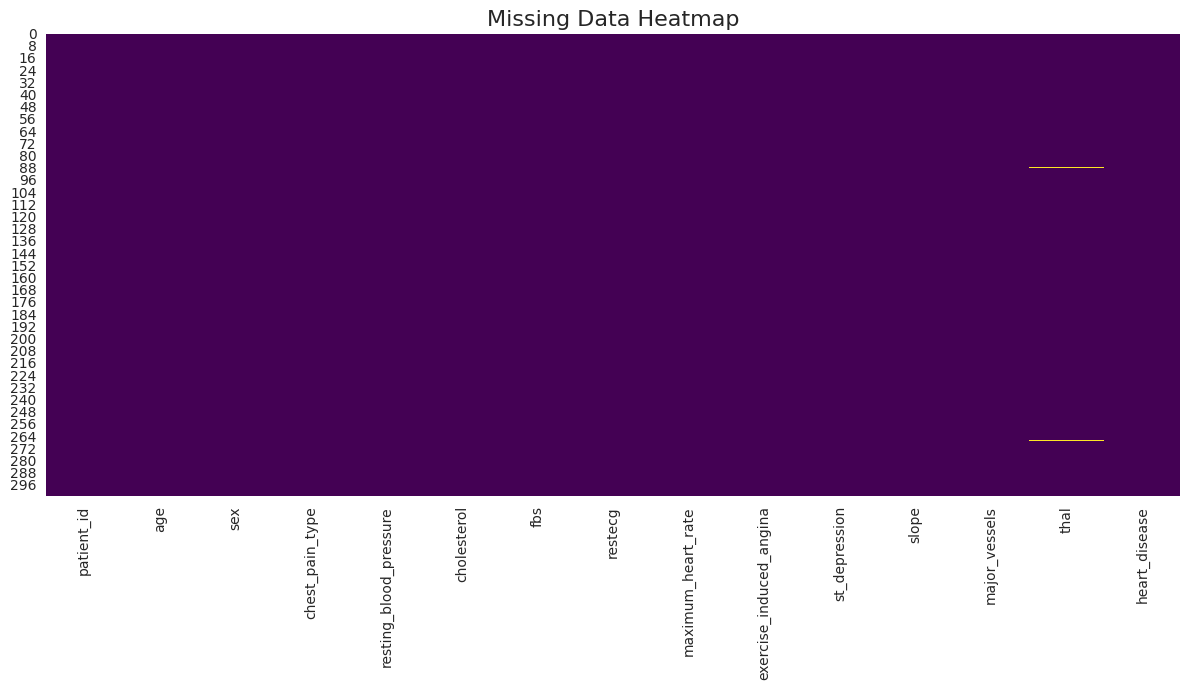

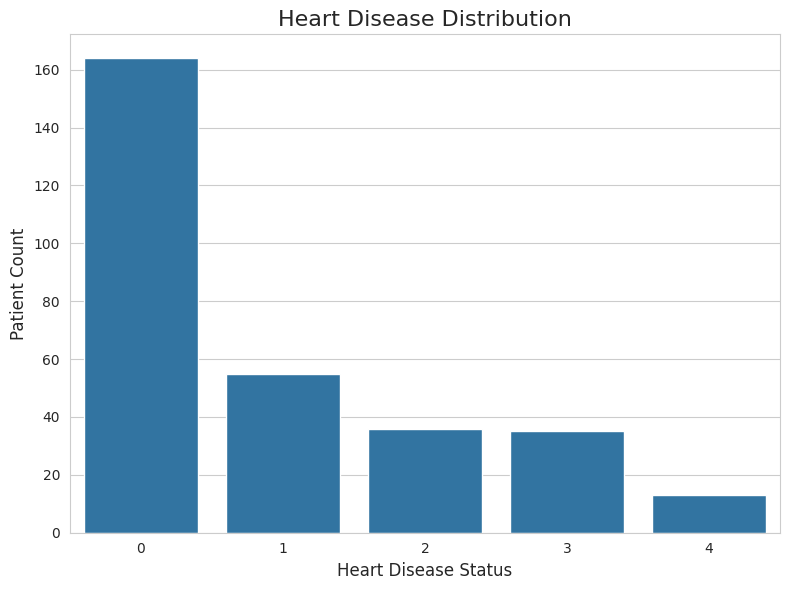

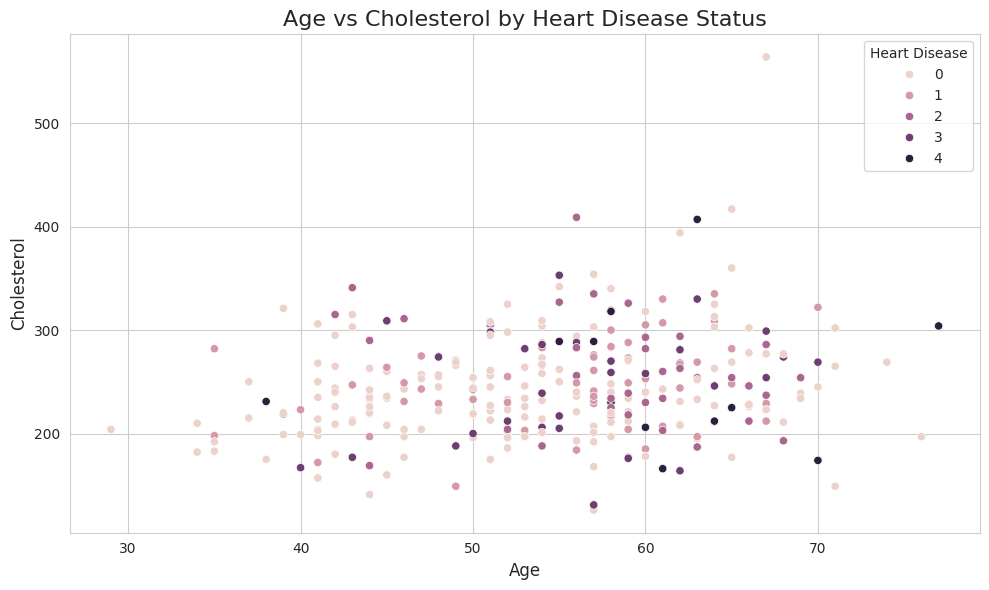

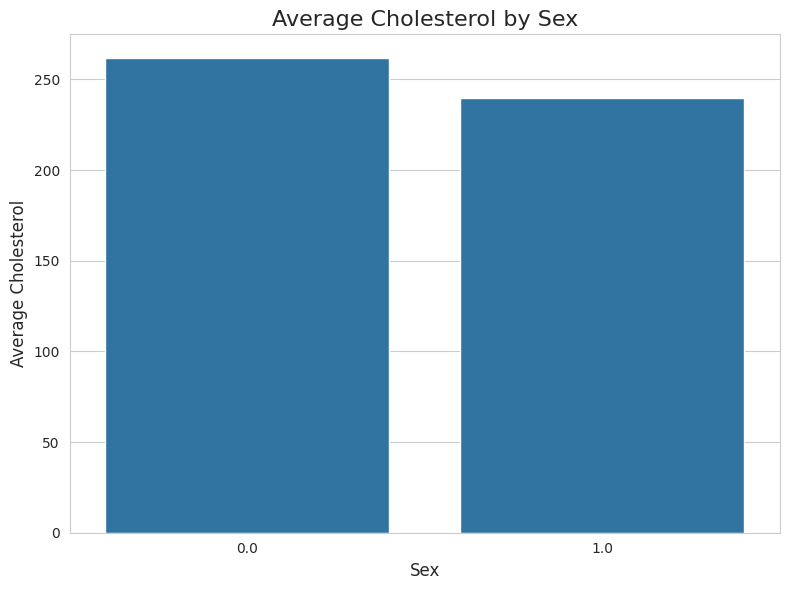

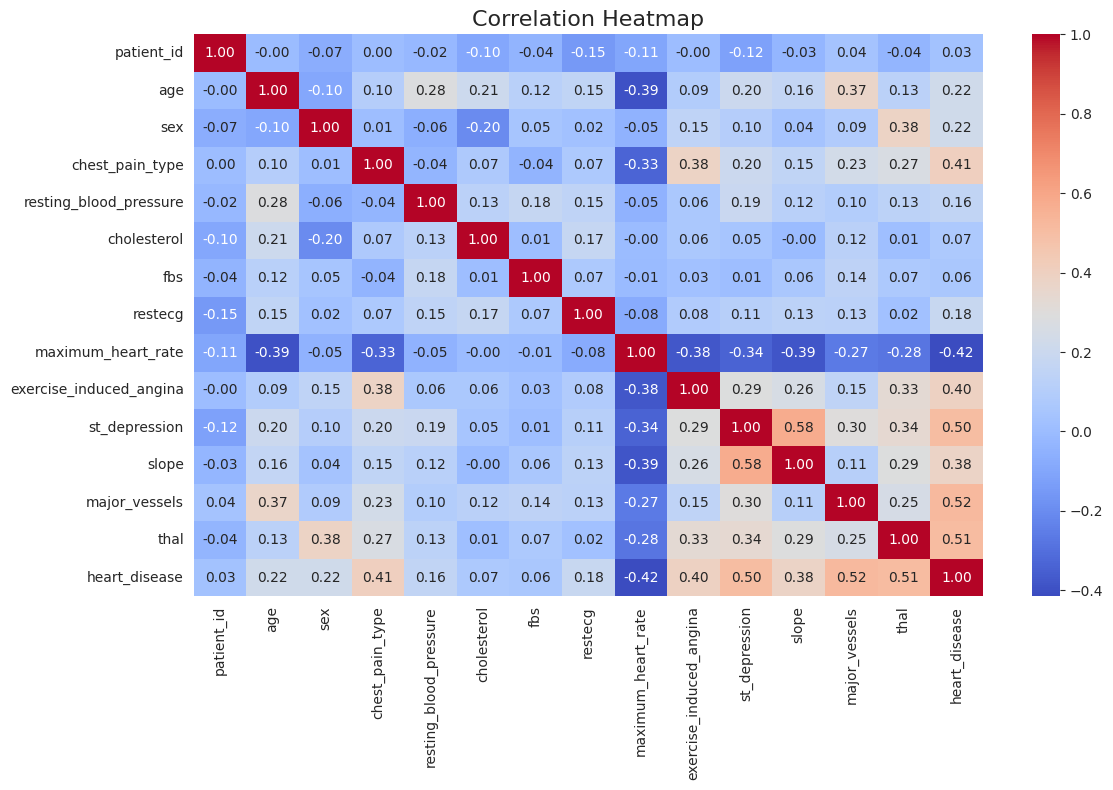


DATA QUALITY SUMMARY

Total Missing Values: 2

Duplicate Records: 0

Average Cholesterol:
246.69306930693068

Average Resting Blood Pressure:
131.68976897689768

Heart Disease Prevalence:
heart_disease
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

VISUALIZATION OUTPUTS GENERATED
Generated: age_distribution_histogram.png
Generated: cholesterol_boxplot.png
Generated: missing_data_heatmap.png
Generated: heart_disease_distribution.png
Generated: age_vs_cholesterol.png
Generated: average_cholesterol_by_sex.png
Generated: correlation_heatmap.png

VISUALIZATION & SUMMARIZATION COMPLETED


In [ ]:
"""
Mini Health Data Warehouse
Part 4: Visualizations & Summarization

Dataset:
UCI Heart Disease Dataset

Objectives:
- Perform exploratory data analysis (EDA)
- Visualize missing data patterns
- Detect and visualize outliers
- Generate clinical trend visualizations
- Summarize cardiovascular risk indicators
- Create publication-quality charts

Author: Your Name
"""

# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from pathlib import Path

# =========================================================
# LOGGING CONFIGURATION
# =========================================================

logging.basicConfig(
    filename='visualization_pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Starting visualization pipeline.")

# =========================================================
# FILE PATHS
# =========================================================

INPUT_FILE = Path(
    "data/processed/merged_heart_disease_data.csv"
)

OUTPUT_PATH = Path("outputs/visualizations")

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# =========================================================
# LOAD DATASET
# =========================================================

try:

    df = pd.read_csv(INPUT_FILE)

    logging.info("Dataset loaded successfully.")

    print("\nDATASET LOADED SUCCESSFULLY")
    print(df.head())

except FileNotFoundError:

    logging.error(f"Dataset not found: {INPUT_FILE}")

    print("Error: Dataset file not found.")

except Exception as e:

    logging.error(f"Dataset loading error: {e}")

    print(f"Unexpected error: {e}")

# =========================================================
# GENERAL DATASET SUMMARY
# =========================================================

try:

    print("\nDATASET SUMMARY")
    print("=" * 60)

    print("\nDataset Shape:")
    print(df.shape)

    print("\nDataset Columns:")
    print(df.columns.tolist())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDescriptive Statistics:")
    print(df.describe())

    logging.info("Dataset summary generated.")

except Exception as e:

    logging.error(f"Summary generation error: {e}")

# =========================================================
# SET VISUALIZATION STYLE
# =========================================================

sns.set_style("whitegrid")

# =========================================================
# HISTOGRAM:
# AGE DISTRIBUTION
# =========================================================

try:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        df['age'],
        bins=15,
        kde=True
    )

    plt.title(
        'Distribution of Patient Age',
        fontsize=16
    )

    plt.xlabel(
        'Age',
        fontsize=12
    )

    plt.ylabel(
        'Frequency',
        fontsize=12
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_PATH / "age_distribution_histogram.png"
    )

    plt.show()

    logging.info("Age distribution histogram created.")

except Exception as e:

    logging.error(f"Histogram generation error: {e}")

# =========================================================
# BOXPLOT:
# CHOLESTEROL OUTLIERS
# =========================================================

try:

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        x=df['cholesterol']
    )

    plt.title(
        'Cholesterol Outlier Detection',
        fontsize=16
    )

    plt.xlabel(
        'Cholesterol Level',
        fontsize=12
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_PATH / "cholesterol_boxplot.png"
    )

    plt.show()

    logging.info("Cholesterol boxplot created.")

except Exception as e:

    logging.error(f"Boxplot generation error: {e}")

# =========================================================
# MISSING DATA HEATMAP
# =========================================================

try:

    plt.figure(figsize=(12, 7))

    sns.heatmap(
        df.isnull(),
        cbar=False,
        cmap='viridis'
    )

    plt.title(
        'Missing Data Heatmap',
        fontsize=16
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_PATH / "missing_data_heatmap.png"
    )

    plt.show()

    logging.info("Missing data heatmap created.")

except Exception as e:

    logging.error(f"Heatmap generation error: {e}")

# =========================================================
# HEART DISEASE DISTRIBUTION
# =========================================================

try:

    plt.figure(figsize=(8, 6))

    sns.countplot(
        x='heart_disease',
        data=df
    )

    plt.title(
        'Heart Disease Distribution',
        fontsize=16
    )

    plt.xlabel(
        'Heart Disease Status',
        fontsize=12
    )

    plt.ylabel(
        'Patient Count',
        fontsize=12
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_PATH / "heart_disease_distribution.png"
    )

    plt.show()

    logging.info("Heart disease distribution plot created.")

except Exception as e:

    logging.error(f"Countplot generation error: {e}")

# =========================================================
# SCATTERPLOT:
# AGE VS CHOLESTEROL
# =========================================================

try:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x='age',
        y='cholesterol',
        hue='heart_disease',
        data=df
    )

    plt.title(
        'Age vs Cholesterol by Heart Disease Status',
        fontsize=16
    )

    plt.xlabel(
        'Age',
        fontsize=12
    )

    plt.ylabel(
        'Cholesterol',
        fontsize=12
    )

    plt.legend(
        title='Heart Disease'
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_PATH / "age_vs_cholesterol.png"
    )

    plt.show()

    logging.info("Scatterplot created successfully.")

except Exception as e:

    logging.error(f"Scatterplot generation error: {e}")

# =========================================================
# BARPLOT:
# AVERAGE CHOLESTEROL BY SEX
# =========================================================

try:

    avg_cholesterol = df.groupby(
        'sex'
    )['cholesterol'].mean().reset_index()

    plt.figure(figsize=(8, 6))

    sns.barplot(
        x='sex',
        y='cholesterol',
        data=avg_cholesterol
    )

    plt.title(
        'Average Cholesterol by Sex',
        fontsize=16
    )

    plt.xlabel(
        'Sex',
        fontsize=12
    )

    plt.ylabel(
        'Average Cholesterol',
        fontsize=12
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_PATH / "average_cholesterol_by_sex.png"
    )

    plt.show()

    logging.info("Barplot created successfully.")

except Exception as e:

    logging.error(f"Barplot generation error: {e}")

# =========================================================
# CORRELATION HEATMAP
# =========================================================

try:

    plt.figure(figsize=(12, 8))

    correlation_matrix = df.corr(
        numeric_only=True
    )

    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap='coolwarm',
        fmt='.2f'
    )

    plt.title(
        'Correlation Heatmap',
        fontsize=16
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_PATH / "correlation_heatmap.png"
    )

    plt.show()

    logging.info("Correlation heatmap created.")

except Exception as e:

    logging.error(f"Correlation heatmap error: {e}")

# =========================================================
# DATA QUALITY SUMMARY
# =========================================================

try:

    print("\nDATA QUALITY SUMMARY")
    print("=" * 60)

    total_missing = df.isnull().sum().sum()

    duplicate_records = df.duplicated().sum()

    print(f"\nTotal Missing Values: {total_missing}")

    print(f"\nDuplicate Records: {duplicate_records}")

    print("\nAverage Cholesterol:")
    print(df['cholesterol'].mean())

    print("\nAverage Resting Blood Pressure:")
    print(df['resting_blood_pressure'].mean())

    print("\nHeart Disease Prevalence:")
    print(df['heart_disease'].value_counts())

    logging.info("Data quality summary completed.")

except Exception as e:

    logging.error(f"Data quality summary error: {e}")

# =========================================================
# FINAL VISUALIZATION SUMMARY
# =========================================================

try:

    print("\nVISUALIZATION OUTPUTS GENERATED")
    print("=" * 60)

    visualization_files = [
        "age_distribution_histogram.png",
        "cholesterol_boxplot.png",
        "missing_data_heatmap.png",
        "heart_disease_distribution.png",
        "age_vs_cholesterol.png",
        "average_cholesterol_by_sex.png",
        "correlation_heatmap.png"
    ]

    for file in visualization_files:
        print(f"Generated: {file}")

    logging.info("Visualization pipeline completed.")

except Exception as e:

    logging.error(f"Final summary error: {e}")

# =========================================================
# PIPELINE COMPLETE
# =========================================================

print("\nVISUALIZATION & SUMMARIZATION COMPLETED")